In [1]:
# Reward-curve comparison across (model, variant) for ablate_game24.
#
# Auto-discovers every run under logs/ablate_game24/<model>/logs/*.log,
# reads the variant tag from the first line ("[<variant_tag>] output -> ..."),
# parses TRL's per-`logging_steps` metric dumps, and exposes:
#   curves[(model, variant)] = {step, correctness, format, reward, loss, entropy}
#
# vllm_*.log files are skipped.
import ast, re
from pathlib import Path

LOG_ROOT = Path("logs/ablate_game24")

# Each TRL log row is a single-line dict literal:  {'loss': 0.03, ..., 'reward': ...}
_DICT_RE = re.compile(r"^\{.*\}\s*$", re.MULTILINE)
# First line of each run log:  [<variant_tag>] output -> /.../<variant_tag>
_TAG_RE  = re.compile(r"^\[([^\]]+)\]")

def parse_metrics(path: Path) -> list[dict]:
    text = path.read_text(errors="ignore")
    out = []
    for m in _DICT_RE.finditer(text):
        try:
            d = ast.literal_eval(m.group(0))
        except (ValueError, SyntaxError):
            continue
        if isinstance(d, dict) and "reward" in d:
            out.append(d)
    return out

def variant_tag(path: Path) -> str | None:
    with path.open(errors="ignore") as f:
        first = f.readline()
    m = _TAG_RE.match(first)
    return m.group(1) if m else None

def to_curves(rows: list[dict], logging_steps: int = 5) -> dict:
    steps = [(i + 1) * logging_steps for i in range(len(rows))]
    return {
        "step":        steps,
        "correctness": [r.get("rewards/correctness_reward/mean", float("nan")) for r in rows],
        "format":      [r.get("rewards/format_reward/mean",      float("nan")) for r in rows],
        "reward":      [r.get("reward",                          float("nan")) for r in rows],
        "loss":        [r.get("loss",                            float("nan")) for r in rows],
        "entropy":     [r.get("entropy",                         float("nan")) for r in rows],
    }

# Discover (model_dir, log_path) pairs.
runs: dict[tuple[str, str], Path] = {}
for model_dir in sorted(LOG_ROOT.iterdir()):
    logs_dir = model_dir / "logs"
    if not logs_dir.is_dir():
        continue
    model = model_dir.name.replace("Qwen__", "")     # "Qwen3-0.6B" etc.
    for log in sorted(logs_dir.glob("*.log")):
        if log.name.startswith("vllm_"):
            continue
        tag = variant_tag(log)
        if tag is None:
            continue
        # On duplicate tag (re-run), keep the most recent file.
        key = (model, tag)
        if key not in runs or log.stat().st_mtime > runs[key].stat().st_mtime:
            runs[key] = log

curves = {key: to_curves(parse_metrics(p)) for key, p in runs.items()}

# Summary table: rows = variants, cols = models.
models   = sorted({m for m, _ in curves})
variants = sorted({v for _, v in curves})

print(f"{'variant':<55s}  " + "  ".join(f"{m:>22s}" for m in models))
print("-" * (57 + 24 * len(models)))
for v in variants:
    cells = []
    for m in models:
        c = curves.get((m, v))
        if c is None or not c["step"]:
            cells.append(f"{'—':>22s}")
        else:
            cells.append(f"{c['correctness'][-1]:>6.3f}/{c['reward'][-1]:<6.3f} ({len(c['step']):>4d})")
    print(f"{v:<55s}  " + "  ".join(cells))
print("\ncell = final_correctness/final_reward (n_log_rows)")


variant                                                              Qwen3-0.6B              Qwen3-1.7B                Qwen3-4B
---------------------------------------------------------------------------------------------------------------------------------
grpo_seed-0                                               0.575/0.700  ( 240)                       —   0.950/1.145  ( 240)
pt-placeholder_adv-token_seed-0                           0.500/0.620  ( 240)                       —   0.875/1.060  ( 240)
pt-velocity-prefix_adv-token_pinj-0.5_L-3_seed-0                              —                       —                       —
pt-velocity_adv-token_seed-0                              0.000/0.150  ( 240)                       —   0.000/0.000  (  22)

cell = final_correctness/final_reward (n_log_rows)


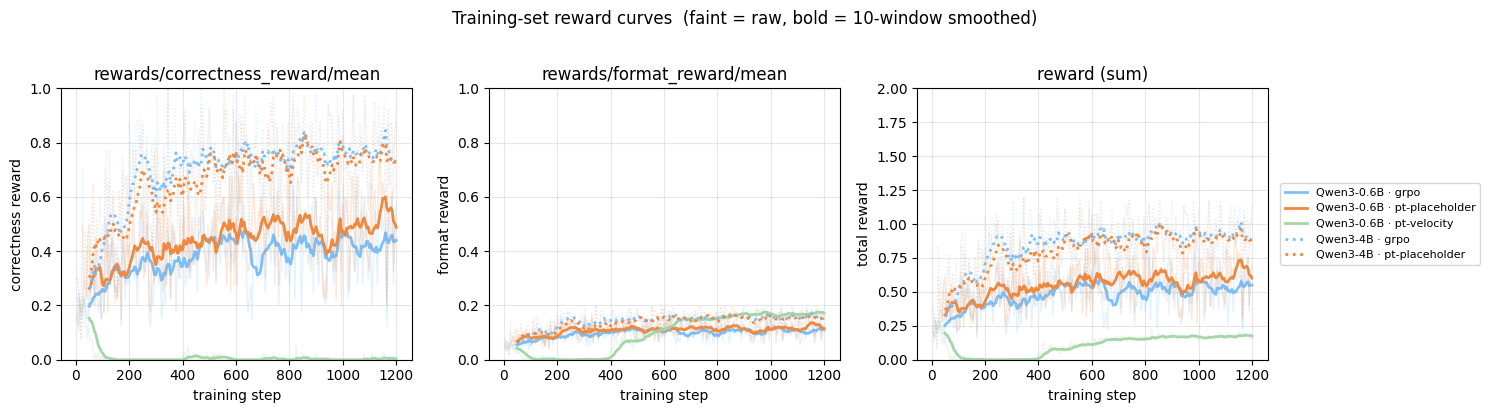

In [2]:
# Reward curves on the TRAINING set (i.e. GRPO's optimization objective).
# Caveat: this is what GRPO is maximizing, so all variants will rise. For a
# generalization comparison, use eval_acc_curve from metrics.json instead.
#
# Color = variant family. Linestyle = model. Runs with < MIN_ROWS log rows
# are skipped (crashed early — see the summary table above).
import numpy as np
import matplotlib.pyplot as plt

MIN_ROWS = 30   # drop crashed/early-exit runs

def smooth(y, k=10):
    y = np.asarray(y, dtype=float)
    if len(y) < k: return y
    pad = np.full(k - 1, np.nan)
    c = np.convolve(np.nan_to_num(y, nan=0.0), np.ones(k) / k, mode="valid")
    return np.concatenate([pad, c])

def variant_family(tag: str) -> str:
    # "pt-velocity-prefix_adv-token_pinj-0.5_L-3_seed-0" -> "pt-velocity-prefix"
    for prefix in ("pt-velocity-prefix", "pt-velocity", "pt-placeholder", "grpo"):
        if tag.startswith(prefix):
            return prefix
    return tag.split("_")[0]

VARIANT_COLORS = {
    "grpo":               "#79c0ff",
    "pt-placeholder":     "#f0883e",
    "pt-velocity":        "#a5d6a7",
    "pt-velocity-prefix": "#ce93d8",
}
MODEL_LINESTYLES = {"Qwen3-0.6B": "-", "Qwen3-1.7B": "--", "Qwen3-4B": ":"}

# Filter to runs with enough data to plot.
plottable = {k: c for k, c in curves.items() if len(c["step"]) >= MIN_ROWS}
if not plottable:
    raise RuntimeError("no runs with >= MIN_ROWS log rows; nothing to plot")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
panels = [
    ("rewards/correctness_reward/mean", "correctness", "correctness reward"),
    ("rewards/format_reward/mean",      "format",      "format reward"),
    ("reward (sum)",                    "reward",      "total reward"),
]

for ax, (title, key, ylabel) in zip(axes, panels):
    for (model, tag), c in sorted(plottable.items()):
        fam = variant_family(tag)
        color = VARIANT_COLORS.get(fam, "#888888")
        ls    = MODEL_LINESTYLES.get(model, "-")
        label = f"{model} · {fam}"
        ax.plot(c["step"], c[key], color=color, alpha=0.20, linewidth=1, linestyle=ls)
        ax.plot(c["step"], smooth(c[key], k=10),
                color=color, linewidth=2, linestyle=ls, label=label)
    ax.set_title(title); ax.set_xlabel("training step"); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

axes[0].set_ylim(0, 1); axes[1].set_ylim(0, 1); axes[2].set_ylim(0, 2)
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.suptitle("Training-set reward curves  (faint = raw, bold = 10-window smoothed)", y=1.02)
plt.tight_layout()
plt.show()


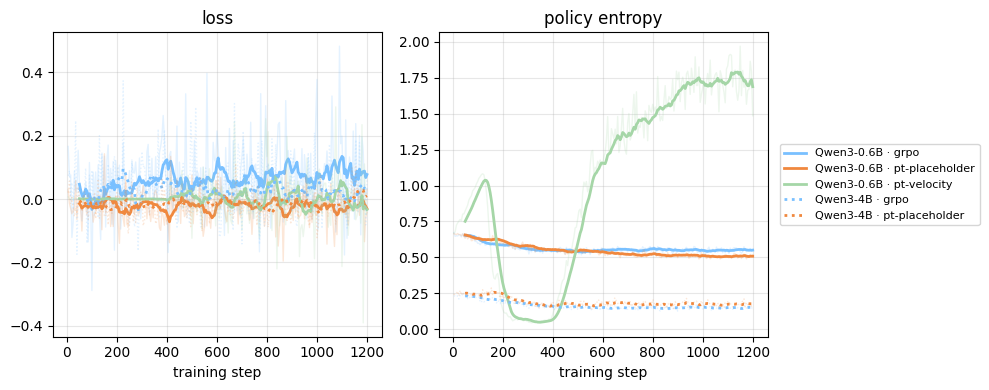

In [3]:
# Bonus: side-by-side of loss and entropy. Loss is NOT directly comparable
# across variants (different objectives), but entropy is.
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, key, label in [(axes[0], "loss", "loss"), (axes[1], "entropy", "policy entropy")]:
    for (model, tag), c in sorted(plottable.items()):
        fam = variant_family(tag)
        color = VARIANT_COLORS.get(fam, "#888888")
        ls    = MODEL_LINESTYLES.get(model, "-")
        ax.plot(c["step"], c[key], color=color, alpha=0.20, linewidth=1, linestyle=ls)
        ax.plot(c["step"], smooth(c[key], k=10),
                color=color, linewidth=2, linestyle=ls, label=f"{model} · {fam}")
    ax.set_title(label); ax.set_xlabel("training step")
    ax.grid(alpha=0.3)
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# (I). build a batch containing 4 rollouts on the same query:
# take 2 rollout from normal GRPO trained model (/Users/fangyuanyu/Implementation/arl/logs/ablate_game24/Qwen__Qwen3-0.6B/grpo_seed-0/rollouts.jsonl)
# one correct, one incorrect
# take 2 rollout from pt-velocity trained model (/Users/fangyuanyu/Implementation/arl/logs/ablate_game24/Qwen__Qwen3-0.6B/pt-velocity_adv-token_seed-0/rollouts.jsonl)
# one correct, one incorrect 

# (II). apply the reward computation (velocity reward) | where we put in all solutions to the query
#       using "VelocityRewardComputer"
#       apply the advantage computation ("token" mode) refer to pertoken_trainer.py line 210 - 227


In [ ]:
# Build a 4-rollout micro-batch on a single shared query and run the velocity
# reward + "token"-mode advantage exactly as PerTokenAdvantageTrainer does.
#
# Layout per query: [grpo_correct, grpo_incorrect, ptvel_correct, ptvel_incorrect]
#
# Caveat: VelocityRewardComputer scores log p(a | q + o[:t]) under whichever
# model you hand it. The training-time scorer is the *live policy* of the
# variant that produced the rollout, but we don't have those checkpoints.
# We use the base model here, which is fine for inspecting the reward shape /
# advantage pooling, but means R_T magnitudes are NOT what each variant saw.

import json
from pathlib import Path
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

import sys; sys.path.insert(0, str(Path.cwd() / "src"))
from src.game24utils import to_chat, enumerate_solutions, verify_24
from src.online_buffer import OnlineBuffer
from src.velocity import VelocityRewardComputer
from src.pertoken_trainer import PerTokenAdvantageTrainer  # noqa: F401  (sanity import)

MODEL_NAME   = "Qwen/Qwen3-0.6B"
GRPO_PATH    = Path("logs/ablate_game24/Qwen__Qwen3-0.6B/grpo_seed-0/rollouts.jsonl")
PTVEL_PATH   = Path("logs/ablate_game24/Qwen__Qwen3-0.6B/pt-velocity_adv-token_seed-0/rollouts.jsonl")
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE        = torch.bfloat16 if DEVICE == "cuda" else torch.float32

def load_rollouts(path: Path) -> list[dict]:
    return [json.loads(l) for l in path.read_text().splitlines() if l.strip()]

grpo_rows  = load_rollouts(GRPO_PATH)
ptvel_rows = load_rollouts(PTVEL_PATH)

# Find a query where each variant has both a correct and an incorrect rollout.
def by_query(rows):
    out: dict[tuple, dict[bool, list[dict]]] = {}
    for r in rows:
        if not r.get("completion"):
            continue
        k = tuple(sorted(r["numbers"]))
        out.setdefault(k, {True: [], False: []})[bool(r["correct"])].append(r)
    return out

g_idx, p_idx = by_query(grpo_rows), by_query(ptvel_rows)
shared = [k for k in g_idx if k in p_idx
          and g_idx[k][True] and g_idx[k][False]
          and p_idx[k][True] and p_idx[k][False]]
assert shared, "no query with correct+incorrect in both variants"
qkey = shared[0]
numbers = list(g_idx[qkey][True][0]["numbers"])
print(f"chosen query numbers={numbers}  (shared across {len(shared)} queries)")

picks = [
    ("grpo  · correct  ", g_idx[qkey][True ][0]),
    ("grpo  · incorrect", g_idx[qkey][False][0]),
    ("ptvel · correct  ", p_idx[qkey][True ][0]),
    ("ptvel · incorrect", p_idx[qkey][False][0]),
]
labels      = [p[0] for p in picks]
completions = [p[1]["completion"] for p in picks]
correctness = [bool(p[1]["correct"]) for p in picks]

# ── load scorer model + tokenizer ─────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE).to(DEVICE).eval()
pad_id = tokenizer.pad_token_id

# ── build the same prompt the trainer feeds GRPO ──────────────────────────
puzzle = {"numbers": numbers, "solutions": enumerate_solutions(tuple(numbers), max_solutions=8)}
chat   = to_chat(puzzle)
prompt_str = tokenizer.apply_chat_template(
    chat["prompt"], tokenize=False, add_generation_prompt=True,
)
prompt_ids_1d = tokenizer(prompt_str, add_special_tokens=False, return_tensors="pt").input_ids[0]

# ── tokenize completions, right-pad into (Bp, T) ──────────────────────────
comp_raw = [tokenizer(c, add_special_tokens=False).input_ids for c in completions]
T = max(len(c) for c in comp_raw)
Bp = len(comp_raw)
P  = prompt_ids_1d.numel()

prompt_ids     = prompt_ids_1d.unsqueeze(0).expand(Bp, P).contiguous().to(DEVICE)
completion_ids = torch.full((Bp, T), pad_id, dtype=torch.long, device=DEVICE)
completion_mask = torch.zeros((Bp, T), dtype=torch.long, device=DEVICE)
for b, ids in enumerate(comp_raw):
    completion_ids[b, :len(ids)]  = torch.tensor(ids, device=DEVICE)
    completion_mask[b, :len(ids)] = 1

# ── seed answer buffer with this puzzle's ground-truth solutions ──────────
answer_buffer = OnlineBuffer(capacity_per_query=64)
qk = tuple(numbers)            # same key the trainer uses (game24_query_key)
for expr in puzzle["solutions"]:
    answer_buffer.add(qk, expr)

vel = VelocityRewardComputer(
    answer_buffer,
    chunk_strategy="uniform",
    chunk_size=16,             # matches script/ablate_game24.py default
    normalize_by_chunk=True,
)

# ── velocity reward ───────────────────────────────────────────────────────
with torch.no_grad():
    r_t, cot_mask = vel.compute_per_token_reward(
        prompt_ids, completion_ids, completion_mask,
        model=model, tokenizer=tokenizer,
        query_keys=[qk] * Bp, correctness=correctness,
        rng=np.random.default_rng(0),
    )

# ── "token" advantage: two pools (CoT, answer-marker), z-scored separately
#    Mirrors src/pertoken_trainer.py:225-242 line-for-line.
m     = completion_mask.bool()
cot_m = cot_mask.bool() & m
ans_m = (~cot_mask.bool()) & m

adv = torch.zeros_like(r_t)
if cot_m.any():
    p_c = r_t[cot_m]
    mu_c, sd_c = p_c.mean(), p_c.std()
    adv[cot_m] = (r_t[cot_m] - mu_c) / (sd_c + 1e-6)
if ans_m.any():
    p_a = r_t[ans_m]
    mu_a, sd_a = p_a.mean(), p_a.std()
    adv[ans_m] = (r_t[ans_m] - mu_a) / (sd_a + 1e-6)

# ── summary ───────────────────────────────────────────────────────────────
print(f"\n{'rollout':<22s}  {'o_len':>6s}  {'cot_tok':>7s}  {'ans_tok':>7s}  "
      f"{'R_T':>10s}  {'r_cot_mean':>11s}  {'adv_cot_µ':>10s}  {'adv_ans_µ':>10s}")
print("-" * 100)
for b, lab in enumerate(labels):
    o_len   = int(m[b].sum())
    n_cot   = int(cot_m[b].sum())
    n_ans   = int(ans_m[b].sum())
    R_T     = float(r_t[b][m[b]].sum())
    rc_mean = float(r_t[b][cot_m[b]].mean()) if n_cot else float("nan")
    a_cot_m = float(adv[b][cot_m[b]].mean()) if n_cot else float("nan")
    a_ans_m = float(adv[b][ans_m[b]].mean()) if n_ans else float("nan")
    print(f"{lab:<22s}  {o_len:>6d}  {n_cot:>7d}  {n_ans:>7d}  "
          f"{R_T:>10.3f}  {rc_mean:>11.5f}  {a_cot_m:>10.3f}  {a_ans_m:>10.3f}")
